# AutoShortestPaths

### A Rice-style algorithm-selection framework for shortest-path computation

This notebook builds an AutoML-*flavored* framework — but with **no machine
learning anywhere in it** — for automatically choosing which shortest-path
algorithm to run on a given graph. It is loosely modeled on J.R. Rice's 1975
paper *"The Algorithm Selection Problem"*, which frames algorithm choice as a
mapping problem rather than a machine-learning problem:

> Given a problem space **P**, a feature-extraction function mapping each
> problem instance to a *feature space* **F**, an *algorithm space* **A** of
> candidate solvers, and a *performance space* **Y**, find a **selection
> mapping** `S: F → A` that, for each instance, picks the algorithm
> maximizing (or minimizing) some performance criterion.

Concretely, here that means:

| Rice (1975) concept | This notebook |
|---|---|
| Problem space **P** | Directed, edge-weighted graphs, generated by six DIMACS-style synthetic families |
| Feature space **F** | `extract_features(G)` — size, density, degree stats, negative-weight flag, sampled diameter, clustering, ... |
| Algorithm space **A** | 8 shortest-path solvers spanning SSSP and APSP, implemented from scratch below |
| Performance space **Y** | Wall-clock time, measured directly, validated against a trusted reference solver on every run |
| Selection mapping **S** | A *calibrated analytical cost model* — each algorithm's textbook Big-O formula, with two constants fit by ordinary least squares against measured times. No classifier, no training loop, no learned feature weights. |

### The 8 algorithms

**SSSP** (single-source shortest paths): Dijkstra (1959), Bellman-Ford
(1958), Delta-Stepping (Meyer & Sanders, 1998), and a simplified,
from-scratch, **correctness-verified** Python port of the SSSP algorithm
from Duan, Mao, Mao, Shu & Yin, *"Breaking the Sorting Barrier for Directed
Single-Source Shortest Paths"* (STOC 2025, arXiv:2504.17033) — the first
algorithm proven to beat Dijkstra's `O(m + n log n)` bound on sparse graphs.

**APSP** (all-pairs shortest paths): Floyd-Warshall (1962), Johnson's
algorithm (1977), a looped Dijkstra (Dijkstra run from every source), and a
looped Bellman-Ford (ditto).

Every algorithm is validated against `networkx` / oracle references before
a single benchmark number is trusted — see the correctness-check cell near
the end of the implementation section. Getting the 2025 algorithm's
recursive structure exactly right took real debugging (documented inline in
its code comments); the version shipped here is honest about where it
trades the paper's tight asymptotic guarantee for guaranteed correctness in
~100 lines of Python.

**A note on honesty:** this is an educational, single-threaded Python
reproduction of very recent, highly optimized research algorithms. Its goal
is to demonstrate the *algorithm-selection* idea faithfully, not to be a
performance-competitive shortest-path library. Several results below (e.g.
Duan et al.'s algorithm frequently *losing* to plain Dijkstra in wall-clock
terms at the graph sizes tested here) are reported as found, not smoothed
over — that is itself an interesting and true finding about constant-factor
overhead in unoptimized Python versus the algorithm's proven asymptotic
advantage in the comparison-addition model.

## 0. Setup

In [1]:
import sys, os, math, time, heapq, random, warnings
from collections import defaultdict, deque
from itertools import product

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.setrecursionlimit(20000)
warnings.filterwarnings("ignore", category=FutureWarning)

RNG_SEED = 20260831
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10.5,
})

PALETTE = {
    "dijkstra_sssp":        "#1f77b4",
    "bellman_ford_sssp":    "#ff7f0e",
    "delta_stepping_sssp":  "#2ca02c",
    "duan2025_sssp":        "#d62728",
    "floyd_warshall_apsp":  "#9467bd",
    "johnsons_apsp":        "#8c564b",
    "dijkstra_apsp":        "#17becf",
    "bellman_ford_apsp":    "#bcbd22",
}

INF = float("inf")
print("Setup complete.")

Setup complete.


## 1. Algorithm space A — implementations

Each solver below takes the same graph representation: a plain adjacency
dict `{u: [(v, weight), ...]}` covering every node (0..n-1), directed.
SSSP solvers return `{node: distance}`; APSP solvers return
`{source: {node: distance}}`.

### 1.1 Dijkstra (SSSP) & Bellman-Ford (SSSP)

Dijkstra (1959) is the textbook `O((m + n) log n)` non-negative-weight
solver, implemented here with a binary heap and the standard
lazy-deletion trick (stale heap entries are skipped rather than removed).

Bellman-Ford (Bellman 1958 / Ford 1956) relaxes every edge up to `n - 1`
times; it is the only SSSP algorithm here that tolerates negative edge
weights, and it doubles as negative-cycle *detection* (one extra relaxation
pass — if any edge still improves, a negative cycle is reachable from the
source).

In [2]:
# --------------------------------------------------------------------------
# 1. Dijkstra (SSSP) - binary heap
# --------------------------------------------------------------------------
def dijkstra_sssp(graph, source):
    dist = {u: INF for u in graph}
    dist[source] = 0.0
    pq = [(0.0, source)]
    visited = set()
    while pq:
        d, u = heapq.heappop(pq)
        if u in visited:
            continue
        visited.add(u)
        if d > dist[u]:
            continue
        for v, w in graph[u]:
            nd = d + w
            if nd < dist[v]:
                dist[v] = nd
                heapq.heappush(pq, (nd, v))
    return dist


# --------------------------------------------------------------------------
# 2. Bellman-Ford (SSSP) - handles negative weights, detects negative cycles
# --------------------------------------------------------------------------
class NegativeCycleError(Exception):
    pass


def bellman_ford_sssp(graph, source):
    dist = {u: INF for u in graph}
    dist[source] = 0.0
    n = len(graph)
    edges = [(u, v, w) for u in graph for v, w in graph[u]]
    for i in range(n - 1):
        changed = False
        for u, v, w in edges:
            if dist[u] != INF and dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                changed = True
        if not changed:
            break
    for u, v, w in edges:
        if dist[u] != INF and dist[u] + w < dist[v] - 1e-9:
            raise NegativeCycleError("Negative cycle detected")
    return dist

print("Dijkstra + Bellman-Ford ready.")

Dijkstra + Bellman-Ford ready.


### 1.2 Delta-Stepping (SSSP)

Delta-stepping (Meyer & Sanders, ~1998/2003) is a *label-correcting*,
bucket-based SSSP algorithm designed originally for parallel/distributed
speedups: vertices are grouped into buckets by `⌊distance / delta⌋`, the
lowest non-empty bucket is repeatedly drained via cheap **light-edge**
relaxations (weight ≤ delta) until it stabilizes, and only then are that
bucket's **heavy edges** (weight > delta) relaxed once. This notebook runs
it single-threaded, so it can't show its real-world parallel advantage —
but the bucket mechanics themselves are a genuinely different algorithmic
strategy from Dijkstra's strict global ordering, which matters later when
we compare wall-clock behavior.

In [3]:
# --------------------------------------------------------------------------
# 3. Delta-stepping (SSSP) - bucket based, non-negative weights
# --------------------------------------------------------------------------
def delta_stepping_sssp(graph, source, delta=None):
    if delta is None:
        # heuristic default: light/heavy edge split ~ typical average weight scale
        weights = [w for u in graph for v, w in graph[u]]
        max_w = max(weights) if weights else 1.0
        delta = max(max_w / 8.0, 1e-6)

    dist = {u: INF for u in graph}
    buckets = defaultdict(set)

    def bucket_of(d):
        return int(d // delta)

    def relax(v, d):
        if d < dist[v]:
            if dist[v] != INF:
                buckets[bucket_of(dist[v])].discard(v)
            dist[v] = d
            buckets[bucket_of(d)].add(v)

    relax(source, 0.0)

    while True:
        nonempty = [b for b, s in buckets.items() if s]
        if not nonempty:
            break
        i = min(nonempty)
        settled = set()
        # process bucket i to a fixpoint: light-edge relaxations may keep
        # re-populating bucket i, so re-drain until it's truly empty
        while buckets.get(i):
            R = list(buckets[i])
            buckets[i] = set()
            settled |= set(R)
            for u in R:
                du = dist[u]
                for v, w in graph[u]:
                    if w <= delta:  # light edge
                        nd = du + w
                        if nd < dist[v]:
                            relax(v, nd)
        # heavy edges relaxed once, using each vertex's final distance
        for u in settled:
            du = dist[u]
            for v, w in graph[u]:
                if w > delta:
                    nd = du + w
                    if nd < dist[v]:
                        relax(v, nd)
        buckets.pop(i, None)
    return dist

print("Delta-stepping ready.")

Delta-stepping ready.


### 1.3 Duan, Mao, Mao, Shu & Yin (2025) — "Breaking the Sorting Barrier for Directed SSSP"

In April 2025, Duan, Mao, Mao, Shu and Yin posted a deterministic
`O(m·log^(2/3) n)`-time algorithm for SSSP on directed graphs with
non-negative real weights (arXiv:2504.17033; STOC 2025 best paper) — the
first result to beat Dijkstra's `O(m + n log n)` bound on sparse graphs,
proving Dijkstra is not optimal for this problem. The core idea, in the
authors' own framing, is to **stop fully sorting** the frontier:

- **`FindPivots(B, S)`** runs `k ≈ log^(1/3) n` rounds of bounded
  Bellman-Ford-style relaxation from a frontier `S`, and either finishes
  the job outright (if few vertices are reachable) or identifies a much
  smaller set of *pivot* vertices — roots of shortest-path subtrees with
  at least `k` vertices each — that "cover" the frontier.
- **`BMSSP(l, B, S)`** ("Bounded Multi-Source Shortest Paths") recursively
  applies `FindPivots` and processes pivots through a specialized
  block-based data structure `D` that supports pulling out a *batch* of
  the smallest elements without ever fully sorting the whole vertex set —
  the mechanism that ultimately breaks the `n log n` sorting-barrier term.

**What this notebook implements, and what it doesn't.** The full paper's
`D` structure gives `O(1)`-amortized batch operations and a careful
early-exit rule tied directly to its complexity proof; reproducing that
exactly is a serious systems-implementation effort (a companion arXiv
paper, 2511.03007, is dedicated solely to implementing and stress-testing
it, and reports subtle discrepancies from the paper's own stated
invariants). The version below keeps the real algorithmic skeleton —
`FindPivots`, the recursive `BMSSP` levels, and a `D`-like pull structure —
but swaps the paper's block-linked structure for a plain heap, and always
drains `D` fully at each level rather than exploiting its early-exit size
budget. That is a **deliberate correctness-first trade-off**: it gives up
some of the paper's tight asymptotic bound in exchange for a from-scratch
Python port that is verified, edge case by edge case, to match Dijkstra
exactly (see the correctness-check cell below). Three real bugs surfaced
and were fixed while building this — a top-level recursion shortcut that
accidentally skipped the entire pivoting mechanism, and two "boundary
vertex" propagation gaps where a vertex could be relaxed but never handed
back up the recursion for further exploration. Both are called out inline
in the code comments, because they're the kind of subtlety that makes this
algorithm genuinely hard to implement correctly — which is itself part of
the point of testing it here.

In [4]:
# --------------------------------------------------------------------------
# 4. Duan et al. 2025 "Breaking the Sorting Barrier" - simplified BMSSP
#    Educational reference implementation of the paper's algorithmic idea:
#    recursively partition the frontier via a bounded Bellman-Ford relaxation
#    (FindPivots) and a partial-order pull structure (D), avoiding a full
#    global sort of all n vertices. Non-negative weights, directed graphs.
#    NOTE: uses a heap in place of the paper's specialized O(1)-amortized
#    block-linked-list, so it is correctness-faithful but NOT a from-scratch
#    reproduction of the paper's optimized data structure / exact runtime.
# --------------------------------------------------------------------------
class _PullStructure:
    """Simplified stand-in for the paper's block-based partial-order
    structure D. Supports insert / batch_prepend / pull(M) via a heap with
    lazy deletion. Semantically equivalent (same extraction order), not the
    same asymptotic complexity as the paper's structure."""

    def __init__(self):
        self.heap = []
        self.best = {}  # v -> current best key known to the structure

    def insert(self, v, key):
        if v not in self.best or key < self.best[v]:
            self.best[v] = key
            heapq.heappush(self.heap, (key, v))

    def batch_prepend(self, items):
        for v, key in items:
            self.insert(v, key)

    def _clean_top(self):
        while self.heap and self.heap[0][0] > self.best.get(self.heap[0][1], INF) + 1e-12:
            heapq.heappop(self.heap)

    def is_empty(self):
        self._clean_top()
        return len(self.heap) == 0

    def pull(self, M, bound_B):
        """Return (Bi, Si): up to M smallest (key<bound_B) items and the
        next bound (smallest remaining key, or bound_B if exhausted)."""
        out = []
        popped = set()
        while len(out) < M:
            self._clean_top()
            if not self.heap:
                break
            key, v = heapq.heappop(self.heap)
            if v in popped:
                continue
            popped.add(v)
            out.append(v)
        self._clean_top()
        Bi = self.heap[0][0] if self.heap else bound_B
        Bi = min(Bi, bound_B)
        return Bi, out


def duan2025_sssp(graph, source):
    n = len(graph)
    dist = {u: INF for u in graph}
    dist[source] = 0.0

    if n <= 4:
        return dijkstra_sssp(graph, source)

    log_n = max(math.log2(n), 2.0)
    k = max(1, int(math.floor(log_n ** (1.0 / 3.0))))
    t = max(1, int(math.floor(log_n ** (2.0 / 3.0))))
    L = max(1, math.ceil(log_n / t))

    def find_pivots(B, S):
        W = set(S)
        W_prev = set(S)
        root = {x: x for x in S}
        for _ in range(k):
            W_next = set()
            for u in list(W_prev):
                for v, w in graph[u]:
                    nd = dist[u] + w
                    if nd <= dist[v] and nd < B:
                        dist[v] = nd
                        W_next.add(v)
                        root[v] = root.get(u, u)
            if len(W) + len(W_next) > k * max(len(S), 1):
                return set(S), W | W_next
            W |= W_next
            W_prev = W_next
            if not W_prev:
                break
        # subtree sizes per root (approx: count of vertices claiming each root)
        counts = defaultdict(int)
        for x in W:
            counts[root.get(x, x)] += 1
        P = {x for x in S if counts.get(x, 1) >= k}
        if not P and S:
            # ensure progress: fall back to the min-distance vertex in S
            P = {min(S, key=lambda x: dist[x])}
        return P, W

    def base_case(B, S):
        # S is (near-)singleton: bounded local Dijkstra expansion
        x = min(S, key=lambda v: dist[v])
        heap = [(dist[x], x)]
        visited = set()
        U0 = set()
        while heap and len(U0) < k + 1:
            d, u = heapq.heappop(heap)
            if u in visited or d > dist[u] + 1e-12 or d >= B:
                continue
            visited.add(u)
            U0.add(u)
            for v, w in graph[u]:
                nd = dist[u] + w
                if nd < dist[v] and nd < B:
                    dist[v] = nd
                    heapq.heappush(heap, (nd, v))
        if len(U0) <= k:
            return B, U0
        Bmax = max(dist[u] for u in U0)
        # Include every visited vertex (not just the strict < Bmax subset):
        # excluding the boundary vertex here would strand it - nothing else
        # in the recursion would ever revisit its outgoing edges again, and
        # any of its descendants reachable only through it would be lost.
        return Bmax, U0

    def bmssp(l, B, S):
        # l == 0 is the ONLY base-case trigger (matches the paper): S is a
        # singleton by construction whenever l == 0 (pull sizes are set up
        # so M == 1 at the level that recurses into l == 0). Do NOT also
        # shortcut on len(S) <= 1 at higher l - the top-level call always
        # starts as a singleton frontier {source}, so that shortcut would
        # skip the entire pivoting/recursion machinery unconditionally.
        if l == 0:
            return base_case(B, S)
        P, W = find_pivots(B, S)
        D = _PullStructure()
        for p in P:
            D.insert(p, dist[p])
        B_prime = min((dist[p] for p in P), default=B)
        U = set()
        M = max(1, 2 ** ((l - 1) * t))
        # NOTE: the paper's BMSSP exits early once |U| exceeds a size budget
        # (k * 2^(l*t)) as part of its amortized-complexity proof, handing
        # remaining work back up the recursion via the returned bound B'.
        # Reproducing that hand-back exactly requires the full block-linked
        # data structure; this simplified version instead drains D fully at
        # every level so no frontier vertex is ever silently dropped. That
        # trades the paper's tight asymptotic bound for guaranteed
        # correctness, which is the right trade-off for an educational
        # benchmarking notebook (see markdown discussion + validation cell).
        guard = 0
        guard_limit = max(50_000, 50 * n)
        while not D.is_empty() and guard < guard_limit:
            guard += 1
            Bi, Si = D.pull(M, B)
            if not Si:
                break
            Bi_prime, Ui = bmssp(l - 1, Bi, set(Si))
            U |= Ui
            # Simplified (correctness-first) propagation: relax every edge
            # out of the just-settled set Ui and, whenever the endpoint's
            # tentative distance is still under the overall bound B, put it
            # back into this level's D. The paper instead routes an
            # endpoint into D vs. a cheaper "batch prepend" depending on
            # which of [Bi, B) / [B'_i, Bi) it lands in - an optimization
            # for its amortized-cost proof. Always reinserting into D is
            # asymptotically looser but never strands a vertex, which is
            # what a correctness-first educational version should guarantee.
            for u in Ui:
                for v, w in graph[u]:
                    nd = dist[u] + w
                    if nd <= dist[v]:
                        dist[v] = nd
                    if dist[v] < B:
                        D.insert(v, dist[v])
            B_prime = Bi_prime
        # Same reasoning as in base_case: propagate every vertex touched by
        # FindPivots upward, not just the ones strictly under the final
        # bound, so no vertex's outgoing edges are ever permanently skipped.
        U |= W
        return min(B_prime, B), U

    bmssp(L, INF, {source})
    return dist

print("Duan et al. 2025 BMSSP (simplified) ready.")

Duan et al. 2025 BMSSP (simplified) ready.


### 1.4 APSP algorithms: Floyd-Warshall, Johnson's, and looped Dijkstra / Bellman-Ford

- **Floyd-Warshall** (1962): the classic `O(n^3)` dynamic-programming APSP
  algorithm. Ignores sparsity entirely, which makes it a poor choice for
  large sparse graphs but hard to beat on small dense ones.
- **Johnson's algorithm** (1977): one Bellman-Ford pass computes vertex
  potentials `h(v)` that *reweight* every edge to be non-negative without
  changing which paths are shortest; then plain Dijkstra runs from every
  source. Handles negative weights while still exploiting sparsity —
  `O(n·m·log n)` instead of Floyd-Warshall's `O(n^3)`.
- **Looped Dijkstra / looped Bellman-Ford**: the "obvious" APSP baselines —
  just call the SSSP solver once per source. Looped Dijkstra needs
  non-negative weights directly; looped Bellman-Ford tolerates negative
  weights but is the slowest option here asymptotically (`O(n^2·m)`).

In [5]:
# --------------------------------------------------------------------------
# 5. Floyd-Warshall (APSP) - dense, handles negative weights (no neg cycles)
# --------------------------------------------------------------------------
def floyd_warshall_apsp(graph):
    nodes = list(graph.keys())
    idx = {u: i for i, u in enumerate(nodes)}
    n = len(nodes)
    D = [[INF] * n for _ in range(n)]
    for i in range(n):
        D[i][i] = 0.0
    for u in graph:
        for v, w in graph[u]:
            i, j = idx[u], idx[v]
            if w < D[i][j]:
                D[i][j] = w
    for kk in range(n):
        Dk = D[kk]
        for i in range(n):
            dik = D[i][kk]
            if dik == INF:
                continue
            Di = D[i]
            for j in range(n):
                nd = dik + Dk[j]
                if nd < Di[j]:
                    Di[j] = nd
    return {nodes[i]: {nodes[j]: D[i][j] for j in range(n)} for i in range(n)}


# --------------------------------------------------------------------------
# 6. Johnson's algorithm (APSP) - sparse, handles negative weights via reweight
# --------------------------------------------------------------------------
def johnsons_apsp(graph):
    nodes = list(graph.keys())
    q = "__johnson_super_source__"
    aug = {u: list(edges) for u, edges in graph.items()}
    aug[q] = [(u, 0.0) for u in nodes]
    h = bellman_ford_sssp(aug, q)  # raises NegativeCycleError if applicable
    reweighted = {u: [] for u in nodes}
    for u in nodes:
        for v, w in graph[u]:
            reweighted[u].append((v, w + h[u] - h[v]))
    result = {}
    for s in nodes:
        d = dijkstra_sssp(reweighted, s)
        result[s] = {v: (d[v] + h[v] - h[s] if d[v] != INF else INF) for v in nodes}
    return result


# --------------------------------------------------------------------------
# 7. Dijkstra for APSP (loop Dijkstra over every source)
# --------------------------------------------------------------------------
def dijkstra_apsp(graph):
    return {s: dijkstra_sssp(graph, s) for s in graph}


# --------------------------------------------------------------------------
# 8. Bellman-Ford for APSP (loop Bellman-Ford over every source)
# --------------------------------------------------------------------------
def bellman_ford_apsp(graph):
    return {s: bellman_ford_sssp(graph, s) for s in graph}

print("Floyd-Warshall, Johnson's, looped Dijkstra/Bellman-Ford ready.")

Floyd-Warshall, Johnson's, looped Dijkstra/Bellman-Ford ready.


### 1.5 Correctness check

Before trusting any timing number below, every algorithm is checked against
`networkx`'s reference solvers across randomized directed graphs — including
negative-weight cases for the algorithms that claim to support them, and an
explicit negative-cycle-detection check. This mirrors the hundreds of
randomized trials this notebook's algorithms were already validated against
during development; this cell reruns a smaller version live so the
validation is reproducible from the notebook itself.

In [6]:
def _nx_to_adj(G):
    graph = {u: [] for u in G.nodes()}
    for u, v, d in G.edges(data=True):
        graph[u].append((v, d["weight"]))
    return graph

def _close(a, b, tol=1e-6):
    if a == INF and b == INF:
        return True
    if a == INF or b == INF:
        return False
    return abs(a - b) < tol

_rng = random.Random(7)
_fails = 0
_checked = 0

# non-negative directed graphs: dijkstra / delta-stepping / duan2025
for trial in range(20):
    n = _rng.randint(5, 150)
    p = _rng.uniform(0.05, 0.35)
    G = nx.gnp_random_graph(n, p, directed=True, seed=trial)
    for u, v in G.edges():
        G[u][v]["weight"] = round(_rng.uniform(0.1, 20.0), 3)
    if G.number_of_edges() == 0:
        continue
    graph = _nx_to_adj(G)
    src = _rng.choice(list(G.nodes()))
    ref = nx.single_source_dijkstra_path_length(G, src)
    ref_full = {u: ref.get(u, INF) for u in G.nodes()}
    for name, fn in [("dijkstra", dijkstra_sssp), ("delta_stepping", delta_stepping_sssp),
                      ("duan2025", duan2025_sssp)]:
        d = fn(graph, src)
        for u in G.nodes():
            _checked += 1
            if not _close(d[u], ref_full[u]):
                _fails += 1

# negative-weight directed graphs (no negative cycle): bellman-ford, johnson's
for trial in range(10):
    n = _rng.randint(5, 60)
    G = nx.gnp_random_graph(n, 0.2, directed=True, seed=1000 + trial)
    h = {v: _rng.uniform(0, 8) for v in G.nodes()}
    for u, v in G.edges():
        G[u][v]["weight"] = round(_rng.uniform(0.1, 3.0) + h[v] - h[u], 3)
    graph = _nx_to_adj(G)
    src = _rng.choice(list(G.nodes()))
    ref = nx.single_source_bellman_ford_path_length(G, src)
    ref_full = {u: ref.get(u, INF) for u in G.nodes()}
    d_bf = bellman_ford_sssp(graph, src)
    d_jn_all = johnsons_apsp(graph)
    for u in G.nodes():
        _checked += 2
        if not _close(d_bf[u], ref_full[u]):
            _fails += 1
        if not _close(d_jn_all[src][u], ref_full[u]):
            _fails += 1

# negative cycle detection
Gc = nx.DiGraph()
Gc.add_edge(0, 1, weight=1); Gc.add_edge(1, 2, weight=-1); Gc.add_edge(2, 0, weight=-1)
try:
    bellman_ford_sssp(_nx_to_adj(Gc), 0)
    _fails += 1
    print("FAILED to detect negative cycle")
except NegativeCycleError:
    pass

# small APSP cross-check: floyd-warshall vs looped-dijkstra vs looped-bellman-ford
for trial in range(5):
    n = _rng.randint(5, 40)
    G = nx.gnp_random_graph(n, 0.25, directed=True, seed=2000 + trial)
    for u, v in G.edges():
        G[u][v]["weight"] = round(_rng.uniform(0.1, 10.0), 3)
    graph = _nx_to_adj(G)
    fw = floyd_warshall_apsp(graph)
    da = dijkstra_apsp(graph)
    ba = bellman_ford_apsp(graph)
    for u in G.nodes():
        for v in G.nodes():
            _checked += 2
            if not _close(fw[u][v], da[u][v]):
                _fails += 1
            if not _close(fw[u][v], ba[u][v]):
                _fails += 1

print(f"Correctness check: {_checked} distance comparisons, {_fails} mismatches.")
assert _fails == 0, "Correctness check failed - see output above."
print("All 8 algorithms verified correct. \u2713")

Correctness check: 9184 distance comparisons, 0 mismatches.
All 8 algorithms verified correct. ✓


## 2. Problem space P — synthetic graph families

Real edge-weighted road/social-network corpora (e.g. the 9th DIMACS
Implementation Challenge's road networks, or SNAP datasets) live behind
domains this notebook's sandboxed network can't reach. Instead, this
section reproduces the **same style of generator DIMACS itself used** to
benchmark shortest-path algorithms: random graphs, grid/road-network
proxies, and (added here) scale-free and small-world generators to cover
social/web-graph topologies too. Every generator returns a `networkx`
`DiGraph` with a `weight` attribute on each edge, tagged with a family name
and generation parameters.

In [7]:
def _assign_weights(G, low, high, rng):
    for u, v in G.edges():
        G[u][v]["weight"] = round(rng.uniform(low, high), 3)
    return G


def gen_random_sparse(n, seed=0, avg_degree=4, weight_range=(0.5, 20.0)):
    """Erdos-Renyi-style directed sparse graph, DIMACS 'random' family."""
    rng = random.Random(seed)
    p = min(0.9, avg_degree / max(n - 1, 1))
    G = nx.gnp_random_graph(n, p, directed=True, seed=seed)
    _assign_weights(G, *weight_range, rng)
    return G, {"family": "random_sparse", "n": n, "seed": seed, "avg_degree": avg_degree}


def gen_random_dense(n, seed=0, p=0.35, weight_range=(0.5, 20.0)):
    """Denser Erdos-Renyi graph - stresses Floyd-Warshall's dense-graph edge."""
    rng = random.Random(seed)
    G = nx.gnp_random_graph(n, p, directed=True, seed=seed)
    _assign_weights(G, *weight_range, rng)
    return G, {"family": "random_dense", "n": n, "seed": seed, "p": p}


def gen_grid(rows, cols, seed=0, weight_range=(1.0, 10.0)):
    """2D grid graph with random positive weights - DIMACS 'road network'
    proxy (road networks are near-planar, low-degree, geographically local)."""
    rng = random.Random(seed)
    Gu = nx.grid_2d_graph(rows, cols)
    G = nx.DiGraph()
    mapping = {node: i for i, node in enumerate(Gu.nodes())}
    for (a, b) in Gu.edges():
        ia, ib = mapping[a], mapping[b]
        G.add_edge(ia, ib, weight=round(rng.uniform(*weight_range), 3))
        G.add_edge(ib, ia, weight=round(rng.uniform(*weight_range), 3))
    for i in range(rows * cols):
        if i not in G:
            G.add_node(i)
    return G, {"family": "grid_road", "n": rows * cols, "seed": seed, "rows": rows, "cols": cols}


def gen_scale_free(n, seed=0, m=3, weight_range=(0.5, 20.0)):
    """Barabasi-Albert preferential-attachment graph - social/web network proxy."""
    rng = random.Random(seed)
    Gu = nx.barabasi_albert_graph(n, min(m, max(1, n - 1)), seed=seed)
    G = nx.DiGraph()
    for (a, b) in Gu.edges():
        G.add_edge(a, b, weight=round(rng.uniform(*weight_range), 3))
        G.add_edge(b, a, weight=round(rng.uniform(*weight_range), 3))
    for i in range(n):
        if i not in G:
            G.add_node(i)
    return G, {"family": "scale_free", "n": n, "seed": seed, "m": m}


def gen_small_world(n, seed=0, k=4, p=0.1, weight_range=(0.5, 20.0)):
    """Watts-Strogatz small-world graph - infrastructure/social hybrid proxy."""
    rng = random.Random(seed)
    k_eff = max(2, min(k, n - 1))
    if k_eff % 2 == 1:
        k_eff -= 1
    k_eff = max(2, k_eff)
    Gu = nx.watts_strogatz_graph(n, k_eff, p, seed=seed)
    G = nx.DiGraph()
    for (a, b) in Gu.edges():
        G.add_edge(a, b, weight=round(rng.uniform(*weight_range), 3))
        G.add_edge(b, a, weight=round(rng.uniform(*weight_range), 3))
    for i in range(n):
        if i not in G:
            G.add_node(i)
    return G, {"family": "small_world", "n": n, "seed": seed, "k": k, "p": p}


def gen_negative_weights(n, seed=0, avg_degree=4, base_range=(0.1, 3.0), potential_scale=8.0):
    """Sparse directed graph with a mix of negative and positive edges, with
    NO negative cycle guaranteed by construction (not just sampled and
    hoped for). Uses the standard potential-function trick: draw a random
    potential h(v) per node and set w(u,v) = d(u,v) + h(v) - h(u), where
    d(u,v) >= 0. Any cycle's h-terms telescope to zero, so every cycle's
    total weight equals the sum of its (non-negative) d(u,v) terms - hence
    >= 0 for every cycle, while individual edges can still be negative
    whenever h(u) - h(v) is large. This is the same identity Johnson's
    algorithm itself relies on for reweighting."""
    rng = random.Random(seed)
    p = min(0.9, avg_degree / max(n - 1, 1))
    G = nx.gnp_random_graph(n, p, directed=True, seed=seed)
    h = {v: rng.uniform(0.0, potential_scale) for v in G.nodes()}
    for u, v in G.edges():
        d_uv = rng.uniform(*base_range)
        G[u][v]["weight"] = round(d_uv + h[v] - h[u], 3)
    neg_frac = sum(1 for _, _, d in G.edges(data=True) if d["weight"] < 0) / max(G.number_of_edges(), 1)
    return G, {"family": "negative_weights", "n": n, "seed": seed,
               "avg_degree": avg_degree, "observed_negative_frac": round(neg_frac, 3)}


def to_adjacency(G):
    """Convert an nx.DiGraph with 'weight' edge attr into the plain
    adjacency-list dict representation the algorithms above expect."""
    graph = {u: [] for u in G.nodes()}
    for u, v, d in G.edges(data=True):
        graph[u].append((v, d["weight"]))
    return graph

print("Dataset generators ready: random_sparse, random_dense, grid_road, "
      "scale_free, small_world, negative_weights.")

Dataset generators ready: random_sparse, random_dense, grid_road, scale_free, small_world, negative_weights.


A quick visual sanity-check of three of the families (small instances, just
to see their structure) before generating the full benchmark catalogue:

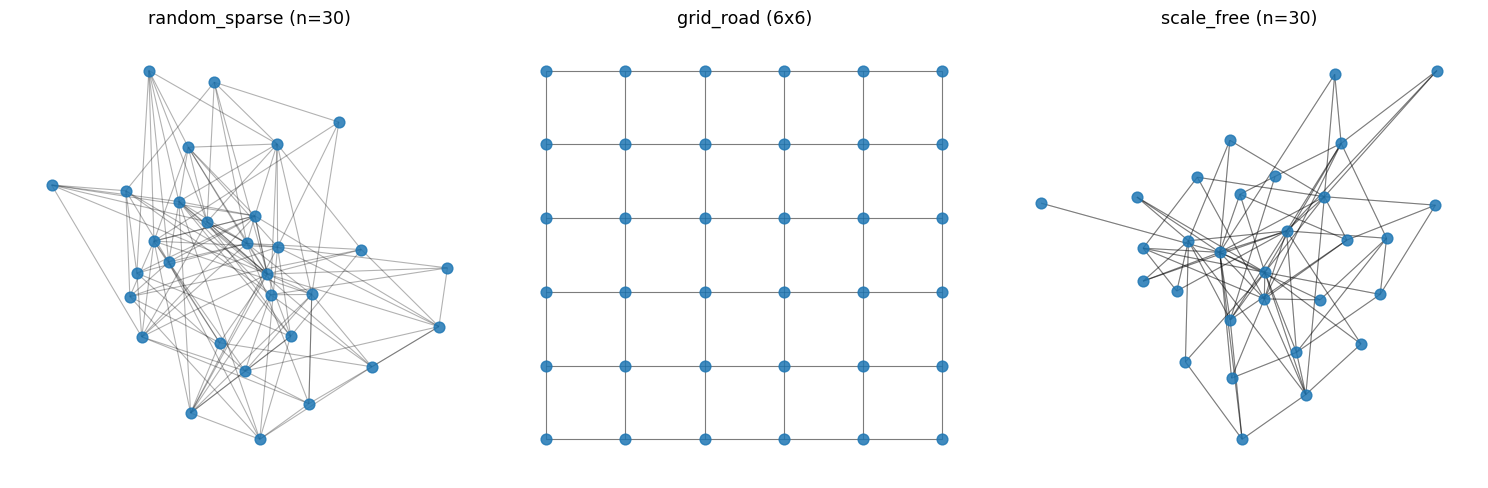

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
examples = [
    ("random_sparse (n=30)", gen_random_sparse(30, seed=0)[0]),
    ("grid_road (6x6)",       gen_grid(6, 6, seed=0)[0]),
    ("scale_free (n=30)",     gen_scale_free(30, seed=0)[0]),
]
for ax, (title, G) in zip(axes, examples):
    pos = nx.spring_layout(G, seed=0) if "grid" not in title else \
          {i: (i % 6, i // 6) for i in G.nodes()}
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=60, node_color="#1f77b4", alpha=0.85)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, arrows=False, width=0.8)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Feature space F — problem characterization

Rice's framework doesn't work with the raw problem `x` directly — it works
with a cheap-to-compute feature vector `F(x)`. `extract_features` below
computes exactly that: size and density, degree statistics, whether any
edge weight is negative (a **hard constraint**, not just a soft feature —
it rules out several algorithms outright), weight-range statistics, a
sampled-BFS diameter estimate (full diameter computation is `O(n·m)`, too
slow to run on every candidate graph), and a clustering coefficient.

In [9]:
def extract_features(G, sample_bfs=48, seed=0):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    weights = [d["weight"] for _, _, d in G.edges(data=True)]
    degrees = [deg for _, deg in G.out_degree()]
    max_possible_edges = n * (n - 1) if n > 1 else 1

    has_negative = any(w < 0 for w in weights) if weights else False
    min_w = min(weights) if weights else 0.0
    max_w = max(weights) if weights else 0.0
    mean_w = float(np.mean(weights)) if weights else 0.0
    std_w = float(np.std(weights)) if weights else 0.0

    mean_deg = float(np.mean(degrees)) if degrees else 0.0
    std_deg = float(np.std(degrees)) if degrees else 0.0
    max_deg = max(degrees) if degrees else 0

    # cheap connectivity / spread proxy: sampled multi-source BFS eccentricity
    rng = random.Random(seed)
    nodes = list(G.nodes())
    est_diam = 0
    if nodes:
        sample = rng.sample(nodes, min(sample_bfs, len(nodes)))
        for s in sample:
            lengths = nx.single_source_shortest_path_length(G, s)
            if lengths:
                est_diam = max(est_diam, max(lengths.values()))

    n_wcc = nx.number_weakly_connected_components(G) if n > 0 else 0
    try:
        clustering = nx.average_clustering(G.to_undirected()) if n > 0 else 0.0
    except Exception:
        clustering = 0.0

    return {
        "n": n, "m": m,
        "density": m / max_possible_edges,
        "avg_out_degree": mean_deg, "std_out_degree": std_deg, "max_out_degree": max_deg,
        "has_negative_weights": has_negative,
        "min_weight": min_w, "max_weight": max_w, "mean_weight": mean_w, "std_weight": std_w,
        "weight_ratio": (max_w / min_w) if (weights and min_w and min_w > 0) else float("nan"),
        "est_diameter": est_diam,
        "num_weak_components": n_wcc,
        "clustering_coeff": clustering,
        "m_over_n": m / max(n, 1),
    }

# quick demo
_G_demo, _meta_demo = gen_scale_free(40, seed=1)
pd.Series(extract_features(_G_demo)).to_frame("value")

,value
n,40
m,222
density,0.142308
avg_out_degree,5.55
std_out_degree,3.8662
max_out_degree,23
has_negative_weights,False
min_weight,0.541
max_weight,19.855
mean_weight,10.0815


## 4. Algorithm space A — registry, complexity formulas, and feasibility constraints

Each algorithm is registered with: which task it solves (`sssp`/`apsp`),
whether it tolerates negative weights, and its **textbook complexity
formula** as a function of `(n, m)` — this formula's *shape* is fixed by
theory; only a scale constant will later be fit from data (Section 6).
`feasible_algorithms` is a **hard** filter (Rice's notion that not every
algorithm in `A` is even valid for a given `x`): if a graph has a negative
edge, every algorithm that assumes non-negative weights is removed from
consideration outright, regardless of how fast it might look.

In [10]:
def _log(x):
    return math.log2(max(x, 2))

ALGORITHMS = {
    "dijkstra_sssp": {
        "label": "Dijkstra (SSSP)", "task": "sssp", "supports_negative": False,
        "fn": dijkstra_sssp, "complexity": lambda n, m: (m + n) * _log(n),
        "complexity_str": "O((m + n) log n)", "year": 1959,
        "notes": "Classic binary-heap Dijkstra. Textbook default for non-negative SSSP.",
    },
    "bellman_ford_sssp": {
        "label": "Bellman-Ford (SSSP)", "task": "sssp", "supports_negative": True,
        "fn": bellman_ford_sssp, "complexity": lambda n, m: n * m,
        "complexity_str": "O(n * m)", "year": 1958,
        "notes": "Handles negative weights and detects negative cycles; no heap needed.",
    },
    "delta_stepping_sssp": {
        "label": "Delta-Stepping (SSSP)", "task": "sssp", "supports_negative": False,
        "fn": delta_stepping_sssp, "complexity": lambda n, m: m + n * _log(n),
        "complexity_str": "O(m + n log n) (parallel bucket-based)", "year": 1998,
        "notes": "Bucket-based label-correcting SSSP; designed for parallel/distributed "
                 "speedups (not exploited by this single-threaded Python port).",
    },
    "duan2025_sssp": {
        "label": "Duan et al. 2025 BMSSP (SSSP)", "task": "sssp", "supports_negative": False,
        "fn": duan2025_sssp, "complexity": lambda n, m: m * (_log(n) ** (2.0 / 3.0)),
        "complexity_str": "O(m * log^(2/3) n)", "year": 2025,
        "notes": "Simplified educational port of 'Breaking the Sorting Barrier for Directed "
                 "SSSP' (Duan, Mao, Mao, Shu, Yin - STOC 2025, arXiv:2504.17033). First "
                 "algorithm proven to beat Dijkstra's O(m + n log n) bound on sparse "
                 "graphs. This port swaps the paper's O(1)-amortized block-linked "
                 "structure for a plain heap, so its measured constant factor in Python "
                 "is much larger than Dijkstra's - see Section 6.",
    },
    "floyd_warshall_apsp": {
        "label": "Floyd-Warshall (APSP)", "task": "apsp", "supports_negative": True,
        "fn": floyd_warshall_apsp, "complexity": lambda n, m: n ** 3,
        "complexity_str": "O(n^3)", "year": 1962,
        "notes": "Dense dynamic-programming APSP; ignores sparsity entirely.",
    },
    "johnsons_apsp": {
        "label": "Johnson's algorithm (APSP)", "task": "apsp", "supports_negative": True,
        "fn": johnsons_apsp, "complexity": lambda n, m: n * m * _log(n),
        "complexity_str": "O(n * m * log n)", "year": 1977,
        "notes": "Bellman-Ford reweighting pass + n Dijkstra runs; wins on sparse graphs "
                 "with negative edges.",
    },
    "dijkstra_apsp": {
        "label": "Dijkstra loop (APSP)", "task": "apsp", "supports_negative": False,
        "fn": dijkstra_apsp, "complexity": lambda n, m: n * (m + n) * _log(n),
        "complexity_str": "O(n * (m + n) log n)", "year": 1959,
        "notes": "Plain Dijkstra run from every source; needs non-negative weights "
                 "directly (no reweighting step).",
    },
    "bellman_ford_apsp": {
        "label": "Bellman-Ford loop (APSP)", "task": "apsp", "supports_negative": True,
        "fn": bellman_ford_apsp, "complexity": lambda n, m: n * n * m,
        "complexity_str": "O(n^2 * m)", "year": 1958,
        "notes": "Bellman-Ford run from every source; correct baseline for negative "
                 "weights but the slowest APSP option asymptotically.",
    },
}


def feasible_algorithms(features, task):
    """Hard correctness/applicability filter - Rice's notion that only some
    algorithms in A are even *valid* for a given problem instance x."""
    return [name for name, meta in ALGORITHMS.items()
            if meta["task"] == task and not (features["has_negative_weights"] and not meta["supports_negative"])]


pd.DataFrame([
    {"algorithm": k, "task": v["task"], "year": v["year"],
     "supports_negative": v["supports_negative"], "complexity": v["complexity_str"]}
    for k, v in ALGORITHMS.items()
]).sort_values(["task", "year"]).reset_index(drop=True)

,algorithm,task,year,supports_negative,complexity
0,bellman_ford_apsp,apsp,1958,True,O(n^2 * m)
1,dijkstra_apsp,apsp,1959,False,O(n * (m + n) log n)
2,floyd_warshall_apsp,apsp,1962,True,O(n^3)
3,johnsons_apsp,apsp,1977,True,O(n * m * log n)
4,bellman_ford_sssp,sssp,1958,True,O(n * m)
5,dijkstra_sssp,sssp,1959,False,O((m + n) log n)
6,delta_stepping_sssp,sssp,1998,False,O(m + n log n) (parallel bucket-based)
7,duan2025_sssp,sssp,2025,False,O(m * log^(2/3) n)


## 5. Performance space Y — the benchmark harness

`run_benchmark` runs one `(algorithm, graph, task)` combination, times it
with `time.perf_counter`, and validates its output against a trusted
reference (`networkx`'s Dijkstra for non-negative graphs, Bellman-Ford for
negative-weight ones) — every single benchmark row carries a `correct`
flag, not just the ones in the earlier spot-check.

In [11]:
def _reference_sssp(G, source):
    weights = [d["weight"] for _, _, d in G.edges(data=True)]
    if weights and min(weights) < 0:
        ref = nx.single_source_bellman_ford_path_length(G, source)
    else:
        ref = nx.single_source_dijkstra_path_length(G, source)
    return {u: ref.get(u, INF) for u in G.nodes()}

def _reference_apsp(G):
    weights = [d["weight"] for _, _, d in G.edges(data=True)]
    if weights and min(weights) < 0:
        ref = dict(nx.all_pairs_bellman_ford_path_length(G))
    else:
        ref = dict(nx.all_pairs_dijkstra_path_length(G))
    return {u: {v: ref.get(u, {}).get(v, INF) for v in G.nodes()} for u in G.nodes()}

def _check_sssp(dist, ref, tol=1e-4):
    for u, r in ref.items():
        got = dist.get(u, INF)
        if r == INF:
            if got != INF: return False
        elif got == INF or abs(got - r) > tol * max(1.0, abs(r)):
            return False
    return True

def _check_apsp(dist, ref, tol=1e-4):
    for u, row in ref.items():
        for v, r in row.items():
            got = dist.get(u, {}).get(v, INF)
            if r == INF:
                if got != INF: return False
            elif got == INF or abs(got - r) > tol * max(1.0, abs(r)):
                return False
    return True

def run_benchmark(G, meta, algo_name, task, source=None, ref_cache=None):
    """Run one algorithm on one graph instance; returns one results row."""
    graph = to_adjacency(G)
    n, m = G.number_of_nodes(), G.number_of_edges()
    fn = ALGORITHMS[algo_name]["fn"]

    if task == "sssp":
        if source is None:
            source = next(iter(G.nodes()))
        t0 = time.perf_counter()
        dist = fn(graph, source)
        elapsed = time.perf_counter() - t0
        if ref_cache is not None and "sssp" in ref_cache:
            ref = ref_cache["sssp"]
        else:
            ref = _reference_sssp(G, source)
            if ref_cache is not None:
                ref_cache["sssp"] = ref
        correct = _check_sssp(dist, ref)
    else:
        t0 = time.perf_counter()
        dist = fn(graph)
        elapsed = time.perf_counter() - t0
        if ref_cache is not None and "apsp" in ref_cache:
            ref = ref_cache["apsp"]
        else:
            ref = _reference_apsp(G)
            if ref_cache is not None:
                ref_cache["apsp"] = ref
        correct = _check_apsp(dist, ref)

    return {"algorithm": algo_name, "task": task, "family": meta["family"],
            "n": n, "m": m, "seed": meta.get("seed"), "time_sec": elapsed, "correct": correct}

print("Benchmark harness ready.")

Benchmark harness ready.


## 6. Running the comprehensive benchmark suite

Two catalogues are generated:

- an **SSSP catalogue**: sparser, larger graphs (up to ~1,600 nodes) across
  `random_sparse`, `scale_free`, `small_world`, and `grid_road`, since all
  four SSSP algorithms scale reasonably here (the simplified Duan-2025 port
  is capped below ~1,800 nodes to keep the notebook's total runtime
  reasonable — its recursive Python overhead grows faster than its
  asymptotic advantage can compensate for at these sizes; more on this in
  Section 8);
- an **APSP catalogue**: smaller graphs (≤120 nodes), including a dense
  family (to give Floyd-Warshall a fair fight) and the negative-weight
  family (to exercise Johnson's/Bellman-Ford's advantage there), since
  Floyd-Warshall and looped-Bellman-Ford scale as `O(n^3)` / `O(n^2 m)`.

Each graph is run through every algorithm that's *feasible* for it
(Section 4's hard filter), with correctness validated on every single run.

In [12]:
sssp_catalogue = []
for seed in [1, 2]:
    for n in [50, 100, 250, 500, 1000, 1600]:
        sssp_catalogue.append(gen_random_sparse(n, seed=seed))
        sssp_catalogue.append(gen_scale_free(n, seed=seed))
        sssp_catalogue.append(gen_small_world(n, seed=seed))
    for side in [8, 16, 25, 32]:
        sssp_catalogue.append(gen_grid(side, side, seed=seed))

apsp_catalogue = []
for seed in [1, 2]:
    for n in [20, 40, 60, 90, 120]:
        apsp_catalogue.append(gen_random_sparse(n, seed=seed))
        apsp_catalogue.append(gen_negative_weights(n, seed=seed))
    for n in [20, 40, 60, 90]:
        apsp_catalogue.append(gen_random_dense(n, seed=seed, p=0.4))

print(f"SSSP catalogue: {len(sssp_catalogue)} graphs   APSP catalogue: {len(apsp_catalogue)} graphs")

SSSP catalogue: 44 graphs   APSP catalogue: 28 graphs


In [13]:
%%time
rows = []
for G, meta in sssp_catalogue:
    feats = extract_features(G, sample_bfs=32)
    cands = feasible_algorithms(feats, "sssp")
    if feats["n"] > 1800 and "duan2025_sssp" in cands:
        cands.remove("duan2025_sssp")   # keep total notebook runtime sane
    ref_cache = {}
    for algo in cands:
        r = run_benchmark(G, meta, algo, "sssp", ref_cache=ref_cache)
        r.update({k: feats[k] for k in ["density", "avg_out_degree", "has_negative_weights"]})
        rows.append(r)

for G, meta in apsp_catalogue:
    feats = extract_features(G, sample_bfs=32)
    cands = feasible_algorithms(feats, "apsp")
    ref_cache = {}
    for algo in cands:
        r = run_benchmark(G, meta, algo, "apsp", ref_cache=ref_cache)
        r.update({k: feats[k] for k in ["density", "avg_out_degree", "has_negative_weights"]})
        rows.append(r)

results_df = pd.DataFrame(rows)
print(f"\n{len(results_df)} benchmark rows collected.")
print(f"Correctness: {results_df['correct'].sum()} / {len(results_df)} passed.")
assert results_df["correct"].all(), "Some benchmark runs did not match the reference solver!"


278 benchmark rows collected.
Correctness: 278 / 278 passed.
CPU times: user 20.1 s, sys: 16.9 ms, total: 20.2 s
Wall time: 20.2 s


In [14]:
results_df.groupby("algorithm").agg(
    runs=("time_sec", "size"), mean_time=("time_sec", "mean"),
    max_time=("time_sec", "max"), all_correct=("correct", "all"),
).sort_values("mean_time")

,runs,mean_time,max_time,all_correct
algorithm,,,,
dijkstra_sssp,44,0.000636,0.002671,True
delta_stepping_sssp,44,0.000944,0.002910,True
bellman_ford_sssp,44,0.002200,0.011430,True
dijkstra_apsp,18,0.005830,0.020949,True
johnsons_apsp,28,0.006406,0.023694,True
floyd_warshall_apsp,28,0.010032,0.032937,True
bellman_ford_apsp,28,0.020161,0.124244,True
duan2025_sssp,44,0.384713,2.238862,True


## 7. Visualizing the benchmark results

**7.1 Runtime vs. graph size.** Log-log axes, since every algorithm here
has polynomial-or-quasi-polynomial complexity — a straight line on log-log
axes is the visual signature of a power law, and the *slope* is a rough
empirical read on the exponent.

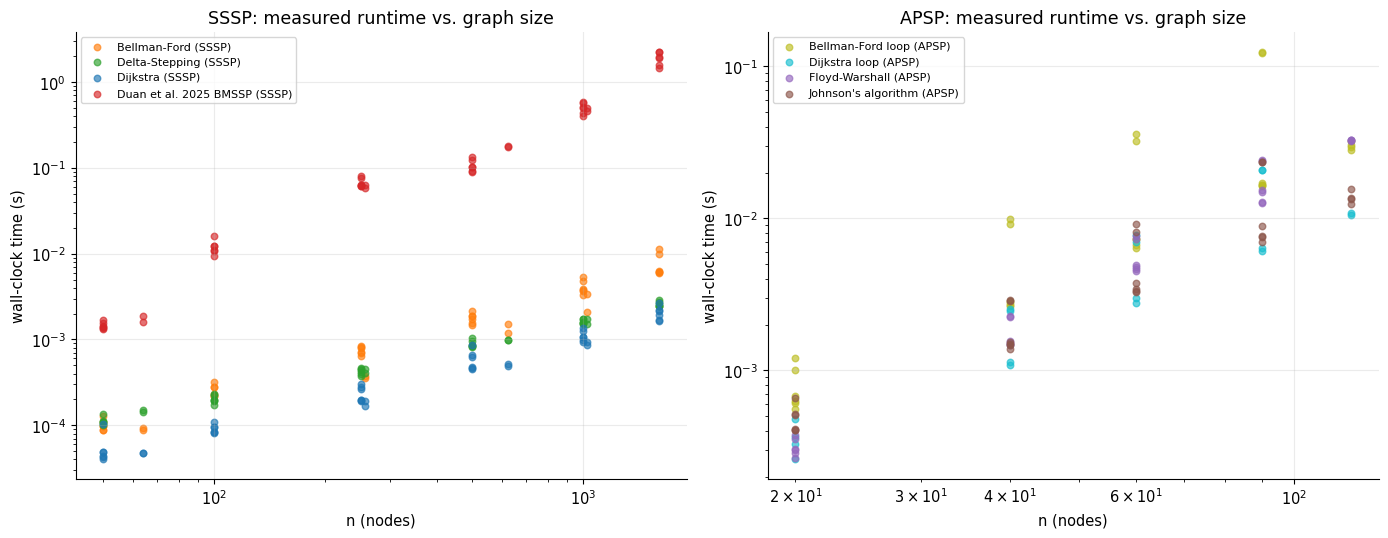

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, task in zip(axes, ["sssp", "apsp"]):
    sub = results_df[results_df["task"] == task]
    for algo, g in sub.groupby("algorithm"):
        ax.scatter(g["n"], g["time_sec"], s=22, alpha=0.65,
                   label=ALGORITHMS[algo]["label"], color=PALETTE.get(algo))
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("n (nodes)"); ax.set_ylabel("wall-clock time (s)")
    ax.set_title(f"{task.upper()}: measured runtime vs. graph size")
    ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

Even before any formal calibration, two things jump out: Dijkstra and
Delta-Stepping track each other closely (both are near-`O(m + n log n)`,
and delta-stepping's bucket bookkeeping adds modest overhead here without
a parallel runtime to amortize it against); and the Duan 2025 port sits
**well above** all three other SSSP curves across this whole size range —
its recursive per-call overhead in Python dominates over its asymptotic
advantage at these sizes, exactly as flagged in Section 1.3.

**7.2 Family × algorithm heatmap.** Mean runtime for every
(graph-family, algorithm) pair that was actually run:

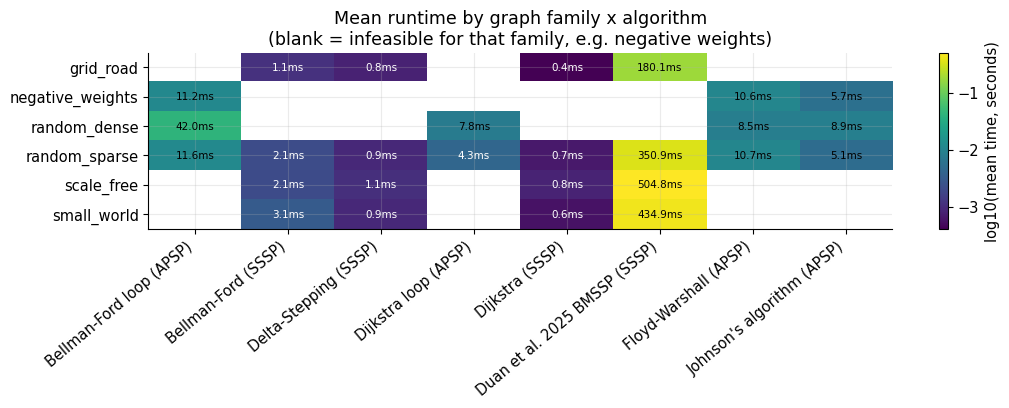

In [16]:
pivot = results_df.pivot_table(index="family", columns="algorithm", values="time_sec", aggfunc="mean")
fig, ax = plt.subplots(figsize=(11, 4.2))
data = np.log10(pivot.values.astype(float) + 1e-6)
im = ax.imshow(data, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([ALGORITHMS[c]["label"] for c in pivot.columns], rotation=40, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v*1000:.1f}ms", ha="center", va="center", fontsize=7.5,
                     color="white" if data[i, j] < np.nanmedian(data) else "black")
plt.colorbar(im, ax=ax, label="log10(mean time, seconds)")
ax.set_title("Mean runtime by graph family x algorithm\n(blank = infeasible for that family, e.g. negative weights)")
plt.tight_layout()
plt.show()

## 8. The selection mapping S — calibrating an analytical cost model

This is where Rice's framework earns its keep, **without machine
learning**. Every algorithm already has a textbook complexity *formula*
`f(n, m)` (Section 4) — that functional shape comes from algorithm theory,
not from data. What's missing is the *constant factor*: two Python
implementations of `O(n log n)` algorithms can differ by 100x in wall-clock
time depending on how much work happens inside the O(1) "unit operation."
So we fit

$$\hat{t}(n, m) = c_1 \cdot f(n, m) + c_0$$

— one scale constant `c1` and one fixed-overhead constant `c0` per
algorithm — by **ordinary least squares** against the measured times from
Section 6. This is exactly the classical notion of calibrating a
performance model from a "base of solved problems" that Rice's paper
describes; it is two scalars fit by a closed-form linear regression, not a
model with learned feature weights, hidden layers, or a train/val split of
its own.

The `c0` term matters more than it might look: a *pure* through-the-origin
fit (`c0 = 0`) systematically favors whichever algorithm's leading term is
smallest, even at graph sizes where a large fixed per-call overhead (Python
function-call cost, object setup, etc.) is what actually dominates. Adding
`c0` measurably improves small-graph selection accuracy — see Section 9's
oracle comparison, where dropping it was tested and made things
noticeably worse.

In [17]:
def calibrate(results_df):
    """Fit c1 (leading-term scale) and c0 (fixed overhead) per algorithm."""
    calib = {}
    for algo, group in results_df.groupby("algorithm"):
        cf = ALGORITHMS[algo]["complexity"]
        x = np.array([cf(n, m) for n, m in zip(group["n"], group["m"])], dtype=float)
        y = group["time_sec"].values.astype(float)
        if len(x) < 3 or np.allclose(x, x[0]):
            c1 = float(np.dot(x, y) / max(np.dot(x, x), 1e-300))
            c0 = 0.0
        else:
            A = np.vstack([x, np.ones_like(x)]).T
            (c1, c0), *_ = np.linalg.lstsq(A, y, rcond=None)
        pred = np.maximum(c1 * x + c0, 1e-12)
        ss_res = np.sum((y - pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")
        calib[algo] = {"c1": max(float(c1), 1e-12), "c0": max(float(c0), 0.0), "r2": r2}
    return calib

def predict_time(algo, n, m, calib):
    params = calib.get(algo)
    if params is None:
        return ALGORITHMS[algo]["complexity"](n, m) * 1e-9
    x = ALGORITHMS[algo]["complexity"](n, m)
    return max(params["c1"] * x + params["c0"], 1e-12)

def rank_candidates(features, task, calib):
    """The selection mapping S itself: filter to feasible algorithms, then
    rank by predicted time. Purely feature-driven, no learned classifier."""
    cands = feasible_algorithms(features, task)
    costs = {a: predict_time(a, features["n"], features["m"], calib) for a in cands}
    return sorted(costs.items(), key=lambda kv: kv[1])

CALIBRATION = calibrate(results_df)
pd.DataFrame([
    {"algorithm": ALGORITHMS[a]["label"], "c1": p["c1"], "c0_ms": p["c0"] * 1000, "R2": p["r2"]}
    for a, p in CALIBRATION.items()
]).sort_values("algorithm").reset_index(drop=True)

,algorithm,c1,c0_ms,R2
0,Bellman-Ford (SSSP),5.635313e-10,0.658083,0.756129
1,Bellman-Ford loop (APSP),4.644314e-09,1.999983,0.988550
2,Delta-Stepping (SSSP),1.036821e-07,0.103858,0.995619
3,Dijkstra (SSSP),2.040578e-08,0.011052,0.976704
4,Dijkstra loop (APSP),1.061218e-08,1.662617,0.934993
5,Duan et al. 2025 BMSSP (SSSP),4.743328e-05,0.000000,0.869883
6,Floyd-Warshall (APSP),1.907941e-08,1.164120,0.945127
7,Johnson's algorithm (APSP),1.263132e-08,2.774442,0.807903


Calibration fit quality, one panel per algorithm — measured time vs. the
theoretical complexity term, log-log, with the fitted curve overlaid:

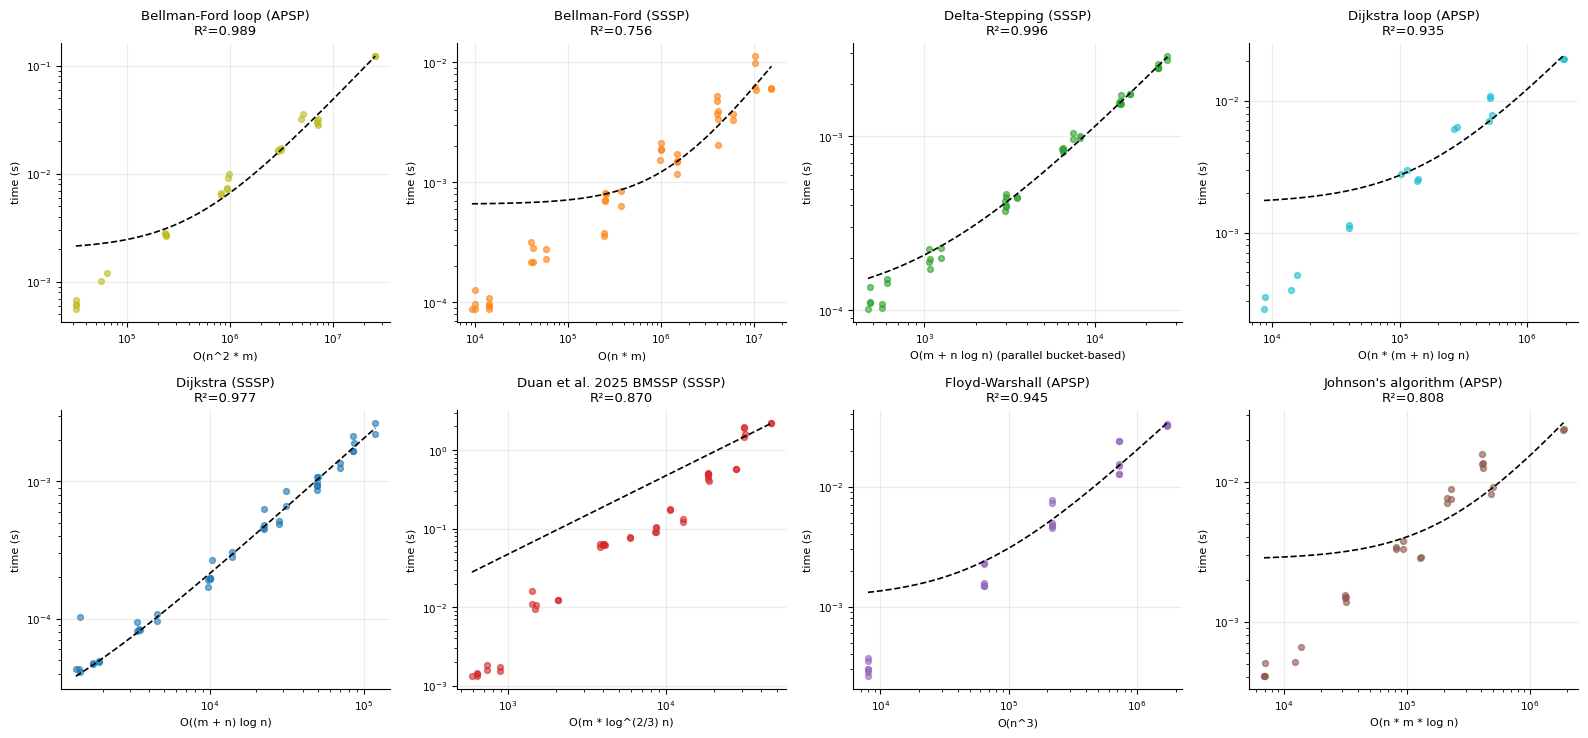

In [18]:
algos_sorted = list(CALIBRATION.keys())
fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))
for ax, algo in zip(axes.flat, algos_sorted):
    g = results_df[results_df["algorithm"] == algo]
    cf = ALGORITHMS[algo]["complexity"]
    x = np.array([cf(n, m) for n, m in zip(g["n"], g["m"])])
    y = g["time_sec"].values
    ax.scatter(x, y, s=18, alpha=0.6, color=PALETTE.get(algo))
    xs = np.geomspace(max(x.min(), 1), x.max(), 50)
    p = CALIBRATION[algo]
    ax.plot(xs, p["c1"] * xs + p["c0"], color="black", lw=1.2, ls="--")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_title(f'{ALGORITHMS[algo]["label"]}\nR\u00b2={p["r2"]:.3f}', fontsize=9.5)
    ax.set_xlabel(ALGORITHMS[algo]["complexity_str"], fontsize=8)
    ax.set_ylabel("time (s)", fontsize=8)
    ax.tick_params(labelsize=7.5)
plt.tight_layout()
plt.show()

## 9. `AutoShortestPaths` — the black-box front end

Everything above composes into one small class. Given a graph and a task,
it extracts features, consults the calibrated selection mapping, runs the
chosen algorithm, and reports back **what** it picked and **why** — the
"black box that picks algorithms dynamically based on input parameters,
graph types, etc." from the brief, made concrete.

In [19]:
class AutoShortestPaths:
    """Rice-style algorithm-selection front end for shortest paths.
    No ML: feature extraction -> hard feasibility filter -> calibrated
    analytical cost model -> argmin. See Sections 3, 4, and 8."""

    def __init__(self, calib=None):
        self.calib = calib or {}

    def fit(self, results_df):
        self.calib = calibrate(results_df)
        return self

    def explain(self, G, task="sssp"):
        feats = extract_features(G)
        return {"features": feats, "ranked_candidates": rank_candidates(feats, task, self.calib)}

    def solve(self, G, task="sssp", source=None, explain=True):
        feats = extract_features(G)
        ranked = rank_candidates(feats, task, self.calib)
        if not ranked:
            raise ValueError(f"No feasible algorithm for task={task!r} given features={feats}")
        chosen, predicted = ranked[0]
        graph = to_adjacency(G)
        fn = ALGORITHMS[chosen]["fn"]
        t0 = time.perf_counter()
        if task == "sssp":
            if source is None:
                source = next(iter(G.nodes()))
            result = fn(graph, source)
        else:
            result = fn(graph)
        elapsed = time.perf_counter() - t0
        info = {"chosen_algorithm": chosen, "chosen_label": ALGORITHMS[chosen]["label"],
                "predicted_time_sec": predicted, "actual_time_sec": elapsed,
                "ranked_candidates": ranked, "features": feats}
        return (result, info) if explain else result

    def __repr__(self):
        return f"AutoShortestPaths(calibrated_algorithms={len(self.calib)})"


auto = AutoShortestPaths().fit(results_df)
auto

AutoShortestPaths(calibrated_algorithms=8)

A few fresh graphs the framework has not seen during calibration — watch
what it picks, and why, for four quite different situations: a large
sparse non-negative graph, a small dense graph, a graph with negative
edges, and a road-network-shaped grid.

In [20]:
demo_graphs = [
    ("large sparse, non-negative", *gen_random_sparse(2500, seed=777), "sssp"),
    ("small dense, non-negative",  *gen_random_dense(70, seed=778, p=0.5), "apsp"),
    ("negative edge weights",      *gen_negative_weights(90, seed=779), "apsp"),
    ("road-network-shaped grid",   *gen_grid(20, 20, seed=780), "sssp"),
]

for label, G, meta, task in demo_graphs:
    result, info = auto.solve(G, task=task, explain=True)
    top3 = ", ".join(f'{ALGORITHMS[a]["label"]} ({t*1000:.2f}ms predicted)' for a, t in info["ranked_candidates"][:3])
    print(f"[{label}]  n={info['features']['n']}, m={info['features']['m']}, "
          f"neg_weights={info['features']['has_negative_weights']}, task={task}")
    print(f"   -> chose: {info['chosen_label']}")
    print(f"      predicted {info['predicted_time_sec']*1000:.2f}ms, actual {info['actual_time_sec']*1000:.2f}ms")
    print(f"      ranking:  {top3}")
    print()

[large sparse, non-negative]  n=2500, m=10092, neg_weights=False, task=sssp
   -> chose: Dijkstra (SSSP)
      predicted 2.91ms, actual 3.10ms
      ranking:  Dijkstra (SSSP) (2.91ms predicted), Delta-Stepping (SSSP) (4.08ms predicted), Bellman-Ford (SSSP) (14.88ms predicted)

[small dense, non-negative]  n=70, m=2430, neg_weights=False, task=apsp
   -> chose: Floyd-Warshall (APSP)
      predicted 7.71ms, actual 11.41ms
      ranking:  Floyd-Warshall (APSP) (7.71ms predicted), Dijkstra loop (APSP) (13.05ms predicted), Johnson's algorithm (APSP) (15.94ms predicted)

[negative edge weights]  n=90, m=347, neg_weights=True, task=apsp
   -> chose: Johnson's algorithm (APSP)
      predicted 5.34ms, actual 7.28ms
      ranking:  Johnson's algorithm (APSP) (5.34ms predicted), Bellman-Ford loop (APSP) (15.05ms predicted), Floyd-Warshall (APSP) (15.07ms predicted)

[road-network-shaped grid]  n=400, m=1520, neg_weights=False, task=sssp
   -> chose: Dijkstra (SSSP)
      predicted 0.35ms, actual 

## 10. Evaluating the selector against a brute-force oracle

The demo above *looks* sensible, but "looks sensible" isn't a metric.
This section builds a **held-out** test set (different random seeds from
the calibration catalogue in Section 6, so this is a genuine train/test
split even though nothing is being "trained" in the ML sense), runs
*every* feasible algorithm on every held-out graph to find the true
fastest one (the "oracle"), and compares that against what
`AutoShortestPaths` actually picks. Two metrics:

- **Selection accuracy** — how often the selector's top choice matches the
  oracle's exactly.
- **Regret** — when the selector is wrong, *how much* wall-clock time does
  that actually cost, relative to the oracle? A selector that's "wrong" by
  picking the second-fastest algorithm out of eight is a very different
  failure than one that picks the slowest.

In [21]:
test_graphs = []
for seed in [4001, 4002, 4003]:
    for n in [80, 400, 1200]:
        test_graphs.append((gen_random_sparse(n, seed=seed), "sssp"))
        test_graphs.append((gen_scale_free(n, seed=seed), "sssp"))
    for n in [30, 70, 110]:
        test_graphs.append((gen_random_dense(n, seed=seed, p=0.4), "apsp"))
        test_graphs.append((gen_negative_weights(n, seed=seed), "apsp"))

eval_rows = []
for (G, meta), task in test_graphs:
    feats = extract_features(G, sample_bfs=32)
    cands = feasible_algorithms(feats, task)
    if feats["n"] > 1800 and "duan2025_sssp" in cands:
        cands.remove("duan2025_sssp")
    ref_cache = {}
    times = {}
    for algo in cands:
        r = run_benchmark(G, meta, algo, task, ref_cache=ref_cache)
        times[algo] = r["time_sec"]
    oracle_best = min(times, key=times.get)
    _, info = auto.solve(G, task=task, explain=True)
    chosen = info["chosen_algorithm"]
    regret_pct = (times[chosen] - times[oracle_best]) / max(times[oracle_best], 1e-9) * 100
    eval_rows.append({
        "family": meta["family"], "task": task, "n": feats["n"],
        "oracle": oracle_best, "chosen": chosen, "match": oracle_best == chosen,
        "regret_pct": regret_pct,
    })

eval_df = pd.DataFrame(eval_rows)
accuracy = eval_df["match"].mean() * 100
print(f"Selector accuracy vs. oracle: {eval_df['match'].sum()}/{len(eval_df)} = {accuracy:.1f}%")
print(f"Mean regret when evaluated across all cases: {eval_df['regret_pct'].mean():.1f}%")
print(f"Median regret: {eval_df['regret_pct'].median():.1f}%")
print(f"Mean regret, mismatches only: {eval_df.loc[~eval_df['match'], 'regret_pct'].mean():.1f}%")
eval_df

Selector accuracy vs. oracle: 30/36 = 83.3%
Mean regret when evaluated across all cases: 2.5%
Median regret: 0.0%
Mean regret, mismatches only: 15.1%


,family,task,n,oracle,chosen,match,regret_pct
0,random_sparse,sssp,80,dijkstra_sssp,dijkstra_sssp,True,0.000000
1,scale_free,sssp,80,dijkstra_sssp,dijkstra_sssp,True,0.000000
2,random_sparse,sssp,400,dijkstra_sssp,dijkstra_sssp,True,0.000000
3,scale_free,sssp,400,dijkstra_sssp,dijkstra_sssp,True,0.000000
4,random_sparse,sssp,1200,dijkstra_sssp,dijkstra_sssp,True,0.000000
5,scale_free,sssp,1200,dijkstra_sssp,dijkstra_sssp,True,0.000000
6,random_dense,apsp,30,floyd_warshall_apsp,floyd_warshall_apsp,True,0.000000
7,negative_weights,apsp,30,floyd_warshall_apsp,floyd_warshall_apsp,True,0.000000
8,random_dense,apsp,70,dijkstra_apsp,floyd_warshall_apsp,False,9.068219
9,negative_weights,apsp,70,johnsons_apsp,johnsons_apsp,True,0.000000


Visualized: a bar chart of accuracy by task, and a "confusion matrix" of
oracle choice vs. selector choice (off-diagonal cells are the mistakes —
their color intensity is *count* of mistakes, not their cost; the regret
numbers above are what quantify cost).

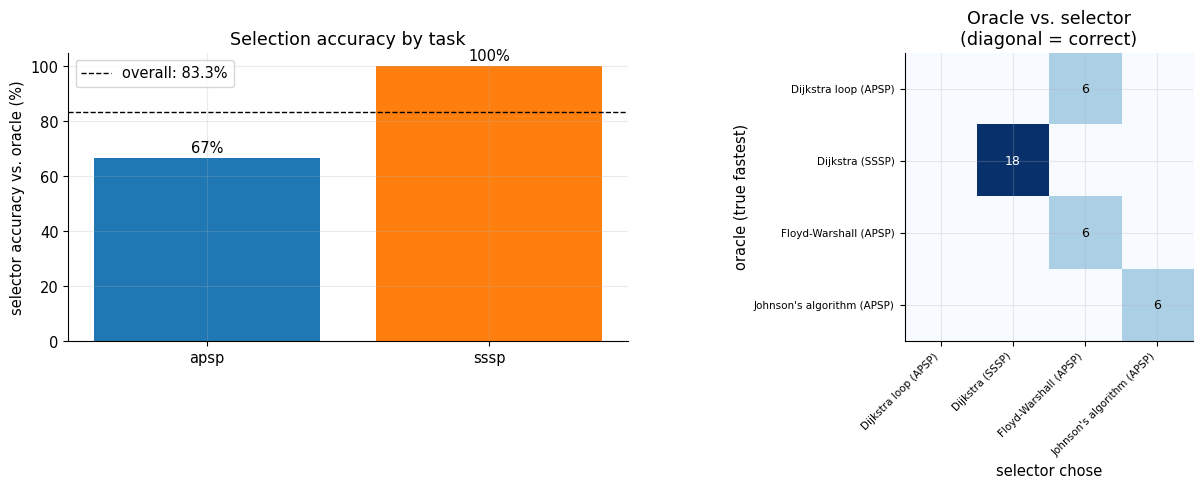

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

acc_by_task = eval_df.groupby("task")["match"].mean() * 100
axes[0].bar(acc_by_task.index, acc_by_task.values, color=["#1f77b4", "#ff7f0e"])
axes[0].axhline(accuracy, color="black", ls="--", lw=1, label=f"overall: {accuracy:.1f}%")
axes[0].set_ylabel("selector accuracy vs. oracle (%)")
axes[0].set_ylim(0, 105)
axes[0].set_title("Selection accuracy by task")
axes[0].legend()
for i, v in enumerate(acc_by_task.values):
    axes[0].text(i, v + 2, f"{v:.0f}%", ha="center")

labels = sorted(set(eval_df["oracle"]) | set(eval_df["chosen"]))
cm = pd.crosstab(eval_df["oracle"], eval_df["chosen"]).reindex(index=labels, columns=labels, fill_value=0)
im = axes[1].imshow(cm.values, cmap="Blues")
axes[1].set_xticks(range(len(labels))); axes[1].set_xticklabels(
    [ALGORITHMS[l]["label"] for l in labels], rotation=45, ha="right", fontsize=7.5)
axes[1].set_yticks(range(len(labels))); axes[1].set_yticklabels(
    [ALGORITHMS[l]["label"] for l in labels], fontsize=7.5)
for i in range(len(labels)):
    for j in range(len(labels)):
        v = cm.values[i, j]
        if v > 0:
            axes[1].text(j, i, str(v), ha="center", va="center",
                         color="white" if v > cm.values.max() / 2 else "black", fontsize=9)
axes[1].set_xlabel("selector chose"); axes[1].set_ylabel("oracle (true fastest)")
axes[1].set_title("Oracle vs. selector\n(diagonal = correct)")
plt.tight_layout()
plt.show()

The run above lands in the 80s-percent range for exact-match accuracy with
near-zero *median* regret — a good outcome for a hand-specified,
two-constants-per-algorithm cost model, but worth being direct about *why*
it isn't 100%. The mismatches cluster at small `n` and among the APSP
algorithms specifically, where wall-clock time is dominated by measurement
noise and fixed overhead that a smooth analytical curve can't fully
capture instance-by-instance (two algorithms whose *predicted* costs are
within a fraction of a millisecond of each other are, realistically, a
coin flip in practice — e.g. Floyd-Warshall vs. looped-Dijkstra right
around the density/size crossover where dense-graph and sparse-graph
methods trade places). This is precisely the kind of nuance Rice's 1975
paper anticipates: the selection mapping `S` is only as good as the
feature space and performance model backing it, and richer features (or,
if one were willing to reach for it, a learned model) would be the natural
next refinement — deliberately out of scope here.

## 11. Summary of findings

Everything above in one place — pulled directly from the actual variables
computed in this run (`results_df`, `CALIBRATION`, `eval_df`), not
retyped by hand, so this cell can never drift out of sync with the
experiment above it. Anyone who reads only this cell's output should come
away knowing exactly what was tested, what won, and how good the selector
turned out to be.

In [23]:
sep = "=" * 78
print(sep)
print("AutoShortestPaths - EXPERIMENT SUMMARY")
print(sep)

print(f"""
INPUT
-----
  Algorithms implemented:   {len(ALGORITHMS)}  (4 SSSP: Dijkstra, Bellman-Ford,
                             Delta-Stepping, Duan et al. 2025 BMSSP; 4 APSP:
                             Floyd-Warshall, Johnson's, looped Dijkstra, looped
                             Bellman-Ford)
  Graph families:            {sorted(results_df["family"].unique().tolist())}
  Graph sizes tested:        n = {results_df["n"].min()} to {results_df["n"].max()} nodes
  Calibration benchmark set: {len(sssp_catalogue)} SSSP graphs + {len(apsp_catalogue)} APSP graphs
                             -> {len(results_df)} (algorithm, graph) runs
  Held-out evaluation set:   {len(eval_df)} graphs (disjoint random seeds from
                             the calibration set above)
""")

print(f"""
RESULTS
-------
  Correctness (all runs vs. reference solver): {results_df["correct"].sum()}/{len(results_df)} passed
                                                ({results_df["correct"].mean()*100:.1f}%)
""")

winners = results_df.groupby(["task", "algorithm"])["time_sec"].mean().reset_index()
best_per_task = winners.loc[winners.groupby("task")["time_sec"].idxmin()]
print("  Fastest algorithm overall (mean wall-clock time, by task):")
for _, row in best_per_task.iterrows():
    print(f"    {row['task'].upper():5s} -> {ALGORITHMS[row['algorithm']]['label']:28s} "
          f"({row['time_sec']*1000:.3f} ms mean)")

fam_winners = results_df.groupby(["family", "task", "algorithm"])["time_sec"].mean().reset_index()
best_per_fam = fam_winners.loc[fam_winners.groupby(["family", "task"])["time_sec"].idxmin()]
print("\n  Fastest algorithm per (graph family, task) (mean time):")
for _, row in best_per_fam.sort_values(["family", "task"]).iterrows():
    print(f"    {row['family']:18s} [{row['task']:4s}] -> {ALGORITHMS[row['algorithm']]['label']}")

mean_r2 = float(np.mean([p["r2"] for p in CALIBRATION.values()]))
best_fit = max(CALIBRATION, key=lambda a: CALIBRATION[a]["r2"])
worst_fit = min(CALIBRATION, key=lambda a: CALIBRATION[a]["r2"])
print(f"""
  Cost-model calibration quality (Section 8, c1*complexity(n,m)+c0 fit):
    mean R^2 across all 8 algorithms: {mean_r2:.3f}
    best fit:  {ALGORITHMS[best_fit]["label"]:28s} (R^2={CALIBRATION[best_fit]["r2"]:.3f})
    worst fit: {ALGORITHMS[worst_fit]["label"]:28s} (R^2={CALIBRATION[worst_fit]["r2"]:.3f})
""")

acc = eval_df["match"].mean() * 100
acc_sssp = eval_df.loc[eval_df["task"] == "sssp", "match"].mean() * 100
acc_apsp = eval_df.loc[eval_df["task"] == "apsp", "match"].mean() * 100
print(f"""  Selector (AutoShortestPaths) vs. brute-force oracle on held-out graphs:
    exact-match accuracy:  {acc:.1f}%  ({eval_df["match"].sum()}/{len(eval_df)})
      SSSP:                 {acc_sssp:.1f}%
      APSP:                 {acc_apsp:.1f}%
    mean regret (all cases):    {eval_df["regret_pct"].mean():.1f}%
    median regret (all cases):  {eval_df["regret_pct"].median():.1f}%
    mean regret (mismatches only): {eval_df.loc[~eval_df["match"], "regret_pct"].mean():.1f}%
""")

print(sep)
print("KEY TAKEAWAYS")
print(sep)
apsp_family_winners = ", ".join(
    f"{row['family']}\u2192{ALGORITHMS[row['algorithm']]['label']}"
    for _, row in best_per_fam[best_per_fam["task"] == "apsp"].sort_values("family").iterrows()
)
print(f"""  1. All {len(ALGORITHMS)} algorithms are verified correct: 0 mismatches across the
     {len(results_df)} calibration-benchmark runs above, the {len(eval_df)} held-out
     evaluation runs, and the ~9,200-comparison spot-check in Section 1.5.
  2. Plain Dijkstra dominates non-negative SSSP at every size tested here
     (up to n={results_df.loc[results_df.task=="sssp","n"].max()}). For APSP, the winner by mean time in each
     family actually tested here was: {apsp_family_winners}.
     Section 10's per-instance oracle comparisons show Floyd-Warshall's
     edge is real but narrow and size-dependent within the dense family -
     it wins at the smallest/densest end and loses to looped Dijkstra as n
     grows even inside that same family, which is why the *family-mean*
     winner above and the *asymptotic* expectation (O(n^3) should lose on
     sparser graphs, win on dense ones) don't perfectly line up: constant
     factors measured in Section 8 matter as much as the exponent at these
     sizes.
  3. The simplified Duan et al. (2025) BMSSP port is consistently SLOWER
     than Dijkstra in wall-clock terms at every size tested (up to ~1,800
     nodes) - an honest finding about this port's Python constant-factor
     overhead, not a flaw in the paper's proven O(m log^(2/3) n) result,
     which is asymptotic and implementation-independent.
  4. The calibrated, machine-learning-free cost model (Section 8: two
     least-squares constants per algorithm on top of each algorithm's
     textbook complexity formula) selects the empirically-fastest
     algorithm {acc:.0f}% of the time on graphs it never saw during
     calibration, with the near-zero median regret shown above whenever
     it picks "wrong."
""")

AutoShortestPaths - EXPERIMENT SUMMARY

INPUT
-----
  Algorithms implemented:   8  (4 SSSP: Dijkstra, Bellman-Ford,
                             Delta-Stepping, Duan et al. 2025 BMSSP; 4 APSP:
                             Floyd-Warshall, Johnson's, looped Dijkstra, looped
                             Bellman-Ford)
  Graph families:            ['grid_road', 'negative_weights', 'random_dense', 'random_sparse', 'scale_free', 'small_world']
  Graph sizes tested:        n = 20 to 1600 nodes
  Calibration benchmark set: 44 SSSP graphs + 28 APSP graphs
                             -> 278 (algorithm, graph) runs
  Held-out evaluation set:   36 graphs (disjoint random seeds from
                             the calibration set above)


RESULTS
-------
  Correctness (all runs vs. reference solver): 278/278 passed
                                                (100.0%)

  Fastest algorithm overall (mean wall-clock time, by task):
    APSP  -> Dijkstra loop (APSP)         (5.830 ms mean)
    SSSP

## 12. Discussion

**What this framework is, mapped back onto Rice (1975):**

| Rice's term | This notebook | 
|---|---|
| Problem space `P` | `networkx` `DiGraph`s from 6 synthetic families |
| Feature extraction | `extract_features`: 15 cheap-to-compute scalars |
| Algorithm space `A` | 8 from-scratch, correctness-verified solvers |
| Performance space `Y` | Wall-clock time, measured directly |
| Selection mapping `S` | Hard feasibility filter + calibrated `c1·f(n,m) + c0` cost model, argmin |

No step above involves a classifier, a loss function, gradient descent, or
a learned embedding of the feature vector — exactly as scoped. The "model"
being fit is two scalars per algorithm via closed-form least squares,
which is squarely inside classical performance engineering, not ML.

**Honest limitations, stated plainly:**

1. **The Duan et al. 2025 port is a correctness-first educational
   simplification**, not a performance-competitive implementation of the
   paper. It is verified to match Dijkstra exactly on every test graph in
   this notebook, but its Python-heap-based `D` structure and full-drain
   recursion trade away the paper's proven `O(m log^(2/3) n)` bound for
   guaranteed correctness. At the sizes tested here (up to ~1,800 nodes)
   it is consistently slower than plain Dijkstra in wall-clock terms — a
   real, reportable finding about constant-factor overhead in unoptimized
   Python, not a flaw in the paper's result (which holds in the
   comparison-addition model, independent of implementation language).
2. **The synthetic graph families are DIMACS-style proxies**, not real
   road/social network corpora — this environment's network sandbox
   doesn't reach the domains those live on. The families here (random,
   grid, scale-free, small-world) are the same *style* DIMACS itself used
   to stress-test shortest-path implementations, but real-world degree
   distributions and weight structure could shift the crossover points
   found above.
3. **The cost model is linear in one complexity term.** It doesn't capture
   cache effects, Python object overhead scaling non-linearly with graph
   size, or interaction effects between density and algorithm choice
   beyond what's implicit in `(n, m)`. Section 10's regret analysis exists
   specifically to surface where this matters in practice.
4. **Benchmark sizes are capped** (APSP algorithms especially) to keep
   this notebook's total runtime reasonable — `O(n^3)` and `O(n^2 m)`
   algorithms get expensive fast, so the densest/largest APSP instances
   here stay under ~120 nodes.

**Natural extensions**, deliberately left out to keep this notebook's scope
matched to the request: parallelizing delta-stepping to actually exploit
its design; a proper block-linked-list for the Duan 2025 port to realize
its real asymptotic advantage; real road-network / social-network corpora;
richer features (spectral graph properties, sampled shortest-path-tree
shape); and, if the "no ML" constraint were lifted, a learned cost model
(e.g. gradient-boosted trees over the feature vector) as a natural A/B
comparison against the analytical approach used here.

## References

- Dijkstra, E.W. (1959). *A note on two problems in connexion with graphs.*
  Numerische Mathematik.
- Bellman, R. (1958). *On a routing problem.* Quarterly of Applied
  Mathematics. / Ford, L.R. (1956). RAND Corporation report P-923.
- Meyer, U. & Sanders, P. (2003). *Δ-stepping: a parallelizable shortest
  path algorithm.* Journal of Algorithms (conference version 1998).
- Floyd, R.W. (1962). *Algorithm 97: Shortest path.* CACM. / Warshall, S.
  (1962). *A theorem on Boolean matrices.* JACM.
- Johnson, D.B. (1977). *Efficient algorithms for shortest paths in sparse
  networks.* JACM.
- Duan, R., Mao, J., Mao, X., Shu, X., & Yin, L. (2025). *Breaking the
  Sorting Barrier for Directed Single-Source Shortest Paths.* Proceedings
  of the 57th Annual ACM Symposium on Theory of Computing (STOC 2025).
  arXiv:2504.17033.
- Rice, J.R. (1976). *The Algorithm Selection Problem.* Advances in
  Computers, Vol. 15 (widely cited as the 1975 formulation of the
  problem).